# Quanto Options pricing under CARMA framework using FFT

## Model parameters definition

In [10]:
#--------------------------------------------------------------------- Imports

import numpy as np
import pandas as pd
from scipy.linalg import expm
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime
from dateutil.relativedelta import relativedelta
from scipy.integrate import quad


#------------------------------------------------------------------- Parameters
# All values from data/levy/carma_montecarlo_final_parameters.csv

# CARMA Parameters — price
b0_X  = 1.0
b1_X  = -1.69107499948807
b2_X  = 0.0856060699524467
a1_X  = 2.7417368516678
a2_X  = 1.85827342924239
a3_X  = 0.161163594914844

# CARMA Parameters — temperature
sigma_T_state = 0.76963298150931
b0_Y  = 1.0
b1_Y  = 0.584420888567256
a1_Y  = 0.834602554797278
a2_Y  = 0.02473622057743

# Gaussian driver for temperature increments
mu_Y    = 0.004626935939183486
sigma_Y = 0.9619333921285353

# NIG driver for idiosyncratic price increments (raw dL_J, not unit-normalised)
mu_X    = 0.032544431425439106
delta_X = 0.3350081939529935
alpha_X = 0.9821566545385684
beta_X  = -0.09493955549441858

# Coupling and idiosyncratic price scale
lambda_coupling = 0.0017485173776097822
sigma_J         = 0.036050456023551204
lambda_sigma_T  = lambda_coupling * sigma_T_state   # ≈ 0.001346


#-------------------------------------------------------- Seasonal trend parameters for Y
'''From nb02 calibration — K_day=3, K_year=1, origin 2020-01-01'''

inputs_Y = {
    "intercept": 10.771397,
    "trend":      0.000006,
    "day_cos_1": -2.773628,
    "day_sin_1": -1.343241,
    "day_cos_2":  0.531266,
    "day_sin_2":  0.000657,
    "day_cos_3":  0.138549,
    "day_sin_3":  0.080022,
    "year_cos_1": -8.946115,
    "year_sin_1": -3.027131,
}

inter_Y = {
    (0,0):  1.607345, (0,1): -0.312687,
    (1,0):  0.756860, (1,1): -0.159530,
    (2,0):  0.222841, (2,1): -0.054528,
    (3,0):  0.260909, (3,1):  0.050530,
    (4,0): -0.384971, (4,1):  0.065902,
    (5,0): -0.039503, (5,1): -0.000543,
}

P_DAY  = 24
P_YEAR = 365.25 * 24


#---------------------------------------------------------- Matrices for log prices X
'''The YUIMA convention holds'''

# Companion matrix A_X of shape (3, 3)
AX = np.array([[0,      1,      0   ],
               [0,      0,      1   ],
               [-a3_X, -a2_X, -a1_X]])

# Noise vector B_X of shape (3, 1) — sigma_J in BX (idiosyncratic price driver)
BX = np.array([[0.0], [0.0], [sigma_J]])

# Selection vector c_X of shape (3,)
cX = np.array([b0_X, b1_X, b2_X])

# Coupling vector Γ of shape (3, 1) — lambda*sigma_T contribution to price
Gamma = np.array([[0.0],
                  [0.0],
                  [lambda_sigma_T]])

#---------------------------------------------------------- Matrices for Temperature Y
'''The YUIMA convention holds'''

# Companion matrix A_Y of shape (2, 2)
AY = np.array([[    0,        1   ],
               [-a2_Y,      -a1_Y]])

# Noise vector B_Y of shape (2, 1) — sigma_T IS in BY
BY = np.array([[0.0], [sigma_T_state]])

# Selection vector c_Y of shape (2,)
cY = np.array([b0_Y, b1_Y])

## Functions definition

In [11]:

#----------------------------------------------- Deterministic function for log prices seasonal part

file = r"../data/deseasonalised/seasonalities.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values" : seasonal_series.values,
                        "month"  : seasonal_series.index.month,
                        "dow"    : seasonal_series.index.dayofweek,
                        "hour"   : seasonal_series.index.hour})
          .groupby(["month", "dow", "hour"])["values"]
          .mean()
          .to_dict())

def Lambda_S(params):
    t = params['end_date']
    key = (t.month, t.dayofweek, t.hour)
    return lookup.get(key, np.nan)


#----------------------------------------------- Deterministic function for temperature seasonal part

def day_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_DAY), np.sin(2*np.pi*1*t/P_DAY),
        np.cos(2*np.pi*2*t/P_DAY), np.sin(2*np.pi*2*t/P_DAY),
        np.cos(2*np.pi*3*t/P_DAY), np.sin(2*np.pi*3*t/P_DAY),
    ])

def year_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_YEAR),
        np.sin(2*np.pi*1*t/P_YEAR),
    ])

def Lambda_Y(params):
    t = params['O']
    y = inputs_Y["intercept"] + inputs_Y["trend"] * t
    y += inputs_Y["day_cos_1"] * np.cos(2*np.pi*1*t/P_DAY)
    y += inputs_Y["day_sin_1"] * np.sin(2*np.pi*1*t/P_DAY)
    y += inputs_Y["day_cos_2"] * np.cos(2*np.pi*2*t/P_DAY)
    y += inputs_Y["day_sin_2"] * np.sin(2*np.pi*2*t/P_DAY)
    y += inputs_Y["day_cos_3"] * np.cos(2*np.pi*3*t/P_DAY)
    y += inputs_Y["day_sin_3"] * np.sin(2*np.pi*3*t/P_DAY)
    y += inputs_Y["year_cos_1"] * np.cos(2*np.pi*1*t/P_YEAR)
    y += inputs_Y["year_sin_1"] * np.sin(2*np.pi*1*t/P_YEAR)
    d = day_features(t)
    v = year_features(t)
    for (i, j), c in inter_Y.items():
        y += c * d[i] * v[j]
    return y


#--------------------------------------------------------------- Discount factor

def discount_factor(r, t):
    r = r / 8760
    return np.exp(-r * t)


#-------------------------------------------------------------- Lévy exponents

def psi_X(theta, mu, delta, alpha, beta):
    """NIG Lévy exponent for idiosyncratic price driver dL_J."""
    g = np.sqrt(alpha**2 - beta**2)
    return (1j * mu * theta
            + delta * (g - np.sqrt(alpha**2 - (beta + 1j*theta)**2)))

def psi_T(theta, mu, sigma):
    """Gaussian Lévy exponent for temperature driver dL_T ~ N(mu, sigma^2) per hour."""
    return 1j * mu * theta - 0.5 * sigma**2 * theta**2


#------------------------------------------------------------- CARMA kernels

def kernel_beta_X(s, T, AX, BX, cX):
    return float(BX.flatten() @ expm(AX.T * (T - s)) @ cX)

def kernel_beta_Y(s, T, AY, BY, cY):
    return float(BY.flatten() @ expm(AY.T * (T - s)) @ cY)

def kernel_gamma_X(s, T, AX, Gamma, cX):
    return float(Gamma.flatten() @ expm(AX.T * (T - s)) @ cX)


#---------------------------------------------------------- Marginal characteristic function for X

def char_function_X(u, T, params, t=0):
    AX, BX, cX = params['AX'], params['BX'], params['cX']
    Gamma       = params['Gamma']
    mu_X, delta_X, alpha_X, beta_X = params['mu_X'], params['delta_X'], params['alpha_X'], params['beta_X']
    mu_Y, sigma_Y = params['mu_Y'], params['sigma_Y']

    # phi_0^X(u): idiosyncratic price driver (NIG)
    def re_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.real(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))
    def im_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.imag(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))

    int_re_X, _ = quad(re_psi_X, t, T, limit=100)
    int_im_X, _ = quad(im_psi_X, t, T, limit=100)

    # phi_0^XY(u, v=0): coupling term (temperature driver, Gaussian)
    def re_psi_T_c(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        return np.real(psi_T(u * g, mu_Y, sigma_Y))
    def im_psi_T_c(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        return np.imag(psi_T(u * g, mu_Y, sigma_Y))

    int_re_T, _ = quad(re_psi_T_c, t, T, limit=100)
    int_im_T, _ = quad(im_psi_T_c, t, T, limit=100)

    return np.exp((int_re_X + int_re_T) + 1j*(int_im_X + int_im_T))


#---------------------------------------------------------- Marginal characteristic function for Y

def char_function_Y(v, T, params, t=0):
    AY, BY, cY = params['AY'], params['BY'], params['cY']
    mu_Y, sigma_Y = params['mu_Y'], params['sigma_Y']

    def re_psi_T(s):
        b = kernel_beta_Y(s, T, AY, BY, cY)
        return np.real(psi_T(v * b, mu_Y, sigma_Y))
    def im_psi_T(s):
        b = kernel_beta_Y(s, T, AY, BY, cY)
        return np.imag(psi_T(v * b, mu_Y, sigma_Y))

    int_re_T, _ = quad(re_psi_T, t, T, limit=100)
    int_im_T, _ = quad(im_psi_T, t, T, limit=100)

    return np.exp(int_re_T + 1j*int_im_T)


#---------------------------------------------------------- Joint characteristic function

def joint_char_function(u, v, T, params, t=0):
    AX, BX, cX = params['AX'], params['BX'], params['cX']
    AY, BY, cY = params['AY'], params['BY'], params['cY']
    Gamma       = params['Gamma']
    mu_X, delta_X, alpha_X, beta_X = params['mu_X'], params['delta_X'], params['alpha_X'], params['beta_X']
    mu_Y, sigma_Y = params['mu_Y'], params['sigma_Y']

    # phi_0^X(u): idiosyncratic price driver (NIG)
    def re_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.real(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))
    def im_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.imag(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))

    int_re_X, _ = quad(re_psi_X, t, T, limit=100)
    int_im_X, _ = quad(im_psi_X, t, T, limit=100)

    # phi_0^XY(u, v): coupling + temperature driver (Gaussian)
    def re_psi_T(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        b = kernel_beta_Y(s, T, AY, BY, cY)
        return np.real(psi_T(u * g + v * b, mu_Y, sigma_Y))
    def im_psi_T(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        b = kernel_beta_Y(s, T, AY, BY, cY)
        return np.imag(psi_T(u * g + v * b, mu_Y, sigma_Y))

    int_re_T, _ = quad(re_psi_T, t, T, limit=100)
    int_im_T, _ = quad(im_psi_T, t, T, limit=100)

    return np.exp((int_re_X + int_re_T) + 1j*(int_im_X + int_im_T))


#-------------------------------------------------------- Fourier transform of the payoff functions

def fourier_drifted_call(u, K_S, lam_S, alpha1):
    K_shifted = K_S + 1000
    K_bar     = np.log(K_shifted) - lam_S
    z         = alpha1 + 1j * u
    return K_shifted * np.exp(-z * K_bar) / ((z - 1) * z)

def fourier_call(v, K_Y, lam_Y, alpha2):
    K_tilde = K_Y - lam_Y
    z       = alpha2 + 1j * v
    return np.exp(-z * K_tilde) / (z**2)

def fourier_h(v, K_Y, lam_Y, alpha2, h_type):
    K_tilde = K_Y - lam_Y
    if h_type == 'indicator':
        return np.exp(-(alpha2 + 1j*v) * K_tilde) / (alpha2 + 1j*v)
    elif h_type == 'none':
        return 1
    elif h_type in ('call', 'put'):
        denom = (1j * v + alpha2)**2
        return np.exp(-(alpha2 + 1j*v) * K_tilde) / denom

## Plain energy call pricing

#### FFT parameters choice

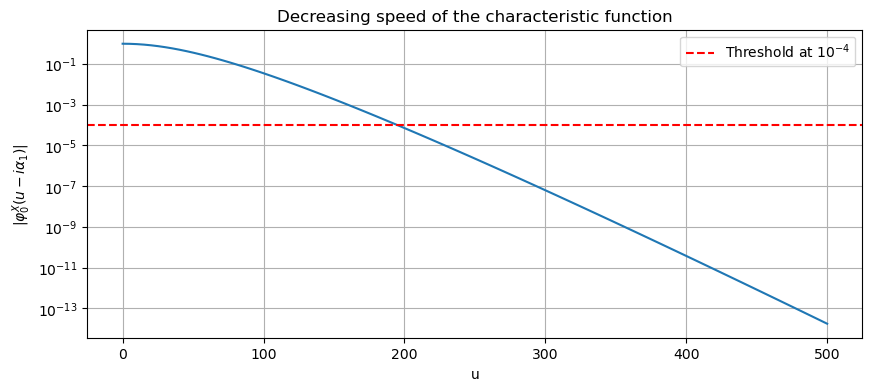

U_max needed : 196.97


In [12]:
#------------------------------------------------------------ Parameters dictionary

start_date  = pd.Timestamp("2026-05-13 12:00:00")
end_date    = pd.Timestamp("2026-06-12 19:00:00")
origin_date = pd.Timestamp("2020-01-01 00:00:00")

T = (end_date - start_date).total_seconds() / 3600
O = (end_date - origin_date).total_seconds() / 3600

params = {'AX': AX, 'BX': BX, 'cX': cX, 'Gamma': Gamma,
          'AY': AY, 'BY': BY, 'cY': cY,
          'mu_X': mu_X, 'delta_X': delta_X, 'alpha_X': alpha_X, 'beta_X': beta_X,
          'mu_Y': mu_Y, 'sigma_Y': sigma_Y,
          'start_date': start_date, 'end_date': end_date, 'origin_date': origin_date,
          'T': T, 'O': O,
          'N': 100_000, 'dt': 1, 'n_steps': T,
          'r': 0, 'K_S': 130, 'K_Y': 10,
          'alpha1': 1.5, 'alpha2': 1.5,
          'eta1': 0.05, 'eta2': 0.05,
          'n_s': 3000, 'M': 6000}


#--------------------------------------------------------- Characteristic function decay check

alpha1 = params['alpha1']
u_range = np.linspace(0, 500, 100)
phi_values = np.array([abs(char_function_X(u - 1j*alpha1, T, params)) for u in u_range])

plt.figure(figsize=(10, 4))
plt.semilogy(u_range, phi_values)
plt.axhline(1e-4, color='r', linestyle='--', label='Threshold at $10^{-4}$')
plt.xlabel('u')
plt.ylabel(r'|$\varphi_0^X(u - i\alpha_1)$|')
plt.title('Decreasing speed of the characteristic function')
plt.legend()
plt.grid(True)
plt.show()

idx = np.where(phi_values < 1e-4)[0]
U_max = u_range[idx[0]] if len(idx) > 0 else u_range[-1]
print(f"U_max needed : {U_max:.2f}")

#### Test for damping parameters and grid edges

In [13]:
#---------------------------------------------------- phi_0 should be negligible on the grid edges

M, T, eta1 = params['M'], params['T'], params['eta1']
u_max = (M//2 - 1) * eta1
u_min = -(M//2) * eta1
phi_u_max = abs(joint_char_function(u_max - 1j*alpha1, 0, T, params))
phi_u_min = abs(joint_char_function(u_min - 1j*alpha1, 0, T, params))

print(f"|phi_0| on max edge : {phi_u_max:.2e}")
print(f"|phi_0| on min edge : {phi_u_min:.2e}")


#------------------------------------------------------ Damping parameter check

def check_damping(alpha1, params, T):
    AX, BX, cX = params['AX'], params['BX'], params['cX']
    alpha_X, beta_X = params['alpha_X'], params['beta_X']
    n_s = params['n_s']

    s_grid = np.linspace(0, T, n_s)
    kernel_betaX = np.array([kernel_beta_X(s, T, AX, BX, cX) for s in s_grid])

    nig_constraint  = np.all(np.abs(beta_X + alpha1 * kernel_betaX) < alpha_X)
    call_constraint = alpha1 > 1

    print(f"Call constraint  (alpha1 > 1) : {'Satisfied' if call_constraint else 'Rejected'}")
    print(f"NIG constraint  (|beta_X + alpha1*beta_X_kernel| < alpha_X) : {'Satisfied' if nig_constraint else 'Rejected'}")
    print(f"max |beta_X + alpha1*kernel| = {np.max(np.abs(beta_X + alpha1*kernel_betaX)):.4f}  (should be < {alpha_X:.4f})")
    print(f"Temperature driver is Gaussian — no domain constraint on coupling term.")

    return call_constraint and nig_constraint


check_damping(alpha1=1.5, params=params, T=params['T'])


|phi_0| on max edge : 1.88e-03
|phi_0| on min edge : 1.87e-03
Call constraint  (alpha1 > 1) : Satisfied
NIG constraint  (|beta_X + alpha1*beta_X_kernel| < alpha_X) : Satisfied
max |beta_X + alpha1*kernel| = 0.1128  (should be < 0.9822)
Temperature driver is Gaussian — no domain constraint on coupling term.


np.True_

#### Pricing

In [14]:
def energy_call_FFT_price(params):

    T     = params['T']
    K_S   = params['K_S']
    r     = params['r']
    lam_S = Lambda_S(params)
    eta1, alpha1 = params['eta1'], params['alpha1']
    M, n_s = params['M'], params['n_s']

    u = (-M//2 + np.arange(M)) * eta1   # (M,)

    w      = np.full(M, eta1)
    w[0]  *= 0.5
    w[-1] *= 0.5

    s_grid = np.linspace(0, T, n_s)

    AX, BX, cX = params['AX'], params['BX'], params['cX']
    Gamma       = params['Gamma']

    bX = np.array([kernel_beta_X(s, T, AX, BX, cX)    for s in s_grid])  # (n_s,)
    gX = np.array([kernel_gamma_X(s, T, AX, Gamma, cX) for s in s_grid])  # (n_s,)

    arg_X = np.outer(u - 1j*alpha1, bX)   # (M, n_s)
    arg_G = np.outer(u - 1j*alpha1, gX)   # (M, n_s)  v=0

    psi_X_values = psi_X(arg_X, params['mu_X'], params['delta_X'], params['alpha_X'], params['beta_X'])  # (M, n_s)
    psi_T_values = psi_T(arg_G, params['mu_Y'], params['sigma_Y'])                                       # (M, n_s)

    phi   = np.exp(np.trapezoid(psi_X_values + psi_T_values, s_grid, axis=1))  # (M,)
    C_hat = fourier_drifted_call(u, K_S, lam_S, alpha1)                        # (M,)

    integral = np.sum(w * C_hat * phi)

    return (np.exp(-r * T) / (2*np.pi) * integral).real


FFT_price = energy_call_FFT_price(params)
print(f"FFT price : {FFT_price:.4f}")


FFT price : 16.8395


## Plain temperature call pricing

#### FFT parameters choice

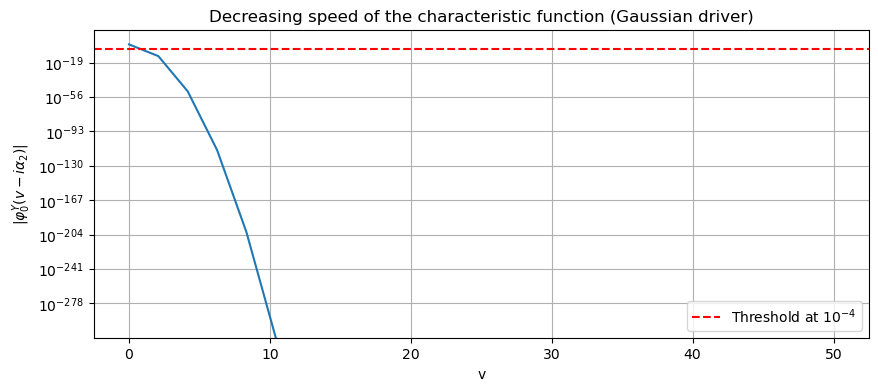

V_max needed : 2.08


In [15]:
#------------------------------------------------------------ Parameters dictionary

start_date  = pd.Timestamp("2026-05-13 12:00:00")
end_date    = pd.Timestamp("2026-06-12 19:00:00")
origin_date = pd.Timestamp("2020-01-01 00:00:00")

T = (end_date - start_date).total_seconds() / 3600
O = (end_date - origin_date).total_seconds() / 3600

params = {'AX': AX, 'BX': BX, 'cX': cX, 'Gamma': Gamma,
          'AY': AY, 'BY': BY, 'cY': cY,
          'mu_X': mu_X, 'delta_X': delta_X, 'alpha_X': alpha_X, 'beta_X': beta_X,
          'mu_Y': mu_Y, 'sigma_Y': sigma_Y,
          'start_date': start_date, 'end_date': end_date, 'origin_date': origin_date,
          'T': T, 'O': O,
          'N': 100_000, 'dt': 1, 'n_steps': T,
          'r': 0, 'K_S': 130, 'K_Y': 18,
          'alpha1': 1.5, 'alpha2': 0.4,
          'eta1': 0.05, 'eta2': 0.05,
          'n_s': 3000, 'M': 6000}


#--------------------------------------------------------- Characteristic function decay check

alpha2 = params['alpha2']
v_range = np.linspace(0, 50, 25)
phi_values = np.array([abs(char_function_Y(v - 1j*alpha2, T, params)) for v in v_range])

plt.figure(figsize=(10, 4))
plt.semilogy(v_range, phi_values)
plt.axhline(1e-4, color='r', linestyle='--', label='Threshold at $10^{-4}$')
plt.xlabel('v')
plt.ylabel(r'|$\varphi_0^Y(v - i\alpha_2)$|')
plt.title('Decreasing speed of the characteristic function (Gaussian driver)')
plt.legend()
plt.grid(True)
plt.show()

idx = np.where(phi_values < 1e-4)[0]
V_max = v_range[idx[0]] if len(idx) > 0 else v_range[-1]
print(f"V_max needed : {V_max:.2f}")

#### Pricing

In [16]:
def temperature_call_FFT_price(params):

    T     = params['T']
    K_Y   = params['K_Y']
    r     = params['r']
    lam_Y = Lambda_Y(params)
    eta2, alpha2 = params['eta2'], params['alpha2']
    M, n_s = params['M'], params['n_s']

    v = (-M//2 + np.arange(M)) * eta2   # (M,)

    w      = np.full(M, eta2)
    w[0]  *= 0.5
    w[-1] *= 0.5

    s_grid = np.linspace(0, T, n_s)

    AY, BY, cY = params['AY'], params['BY'], params['cY']

    bY = np.array([kernel_beta_Y(s, T, AY, BY, cY) for s in s_grid])  # (n_s,)

    arg_Y        = np.outer(v - 1j*alpha2, bY)                           # (M, n_s)
    psi_T_values = psi_T(arg_Y, params['mu_Y'], params['sigma_Y'])       # (M, n_s)

    phi   = np.exp(np.trapezoid(psi_T_values, s_grid, axis=1))   # (M,)
    C_hat = fourier_call(v, K_Y, lam_Y, alpha2)                  # (M,)

    integral = np.sum(w * C_hat * phi)

    return (np.exp(-r * T) / (2*np.pi) * integral).real


FFT_price = temperature_call_FFT_price(params)
print(f"FFT price : {FFT_price:.4f}")


FFT price : 2.1299
